In [1]:
# Install SHAP outside the notebook environment if needed:
# pip install shap

## 1. Import Libraries
### Load required Python libraries for data processing, modeling, and visualization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score, precision_recall_curve, roc_curve
# import shap

C:\Users\patel\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Load Data
### Read the HR Analytics dataset into a DataFrame and inspect its shape and first rows.

In [3]:
df = pd.read_csv('HR_Analytics.csv')
print(df.shape)
df.head()

(1480, 38)


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   str    
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   str    
 3   Attrition                 1480 non-null   str    
 4   BusinessTravel            1480 non-null   str    
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   str    
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   str    
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   str    
 14  HourlyRate         

In [5]:
print("Data Description:", round(df.describe(),2))

Data Description:            Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
count  1480.00    1480.00           1480.00    1480.00         1480.0   
mean     36.92     801.38              9.22       2.91            1.0   
std       9.13     403.13              8.13       1.02            0.0   
min      18.00     102.00              1.00       1.00            1.0   
25%      30.00     465.00              2.00       2.00            1.0   
50%      36.00     800.00              7.00       3.00            1.0   
75%      43.00    1157.00             14.00       4.00            1.0   
max      60.00    1499.00             29.00       5.00            1.0   

       EmployeeNumber  EnvironmentSatisfaction  HourlyRate  JobInvolvement  \
count         1480.00                  1480.00     1480.00         1480.00   
mean          1031.86                     2.72       65.85            2.73   
std            605.96                     1.09       20.33            0.71   
min         

## 3. Data Cleaning
### Remove fixed-value or irrelevant columns, drop duplicates, and prepare the dataset for modeling.

In [6]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears     

In [7]:
df.drop(["EmployeeCount","EmployeeNumber","Over18","StandardHours", "YearsWithCurrManager"], axis=1, inplace=True)

In [8]:
df.drop_duplicates(inplace=True)
print("Duplicate Values:", df.duplicated().sum())

Duplicate Values: 0


## 4. Feature Engineering
### Create derived features such as age groups to help capture patterns better.

In [9]:
bins = [18,25,35,45,60]
labels = [0, 1, 2, 3]

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
# df['AgeGroup'] = df['AgeGroup'].astype(int)

In [10]:
df['AgeGroup'].unique()

[NaN, 0, 1, 2, 3]
Categories (4, int64): [0 < 1 < 2 < 3]

## 5. Exploratory Data Analysis (EDA)
### Visualize key relationships and patterns in the dataset.


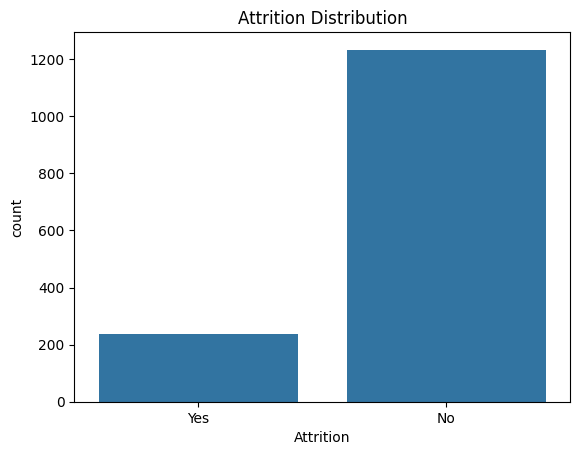

In [11]:
## Attrition Distribution
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

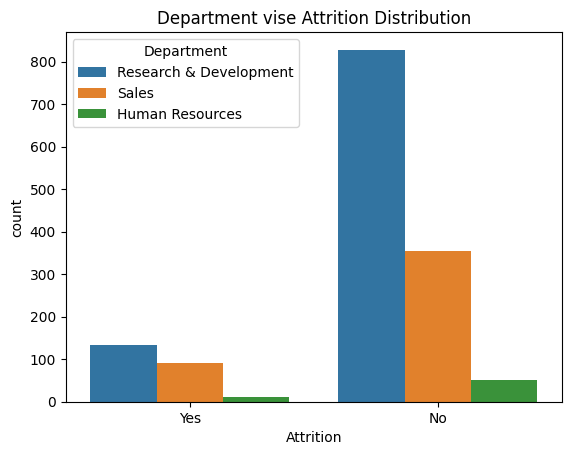

In [12]:
## Depratment vise Attrition Distribution
sns.countplot(x='Attrition', data=df , hue='Department')
plt.title("Department vise Attrition Distribution")
plt.show()

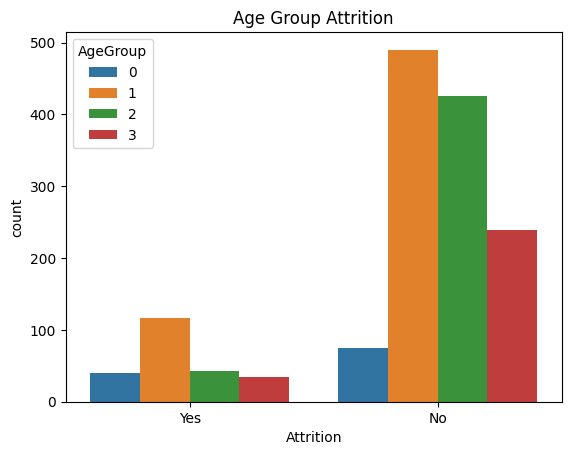

In [13]:
## Age Group Attrition 
sns.countplot(x = 'Attrition', data=df, hue='AgeGroup')
plt.title('Age Group Attrition')
plt.show()

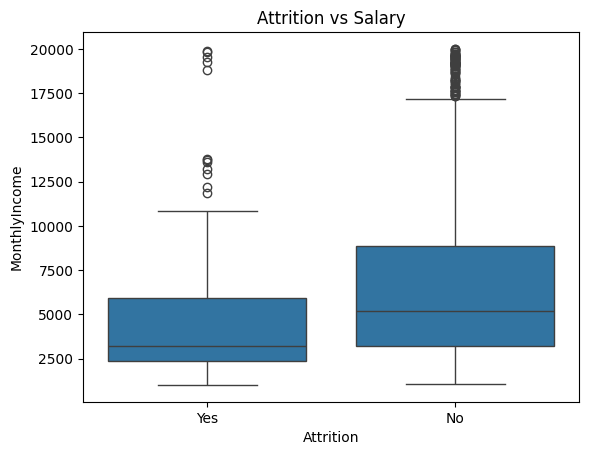

In [14]:
## Attrition vs Salary
sns.boxplot(x='Attrition', y ='MonthlyIncome', data = df)
plt.title("Attrition vs Salary")
plt.show()

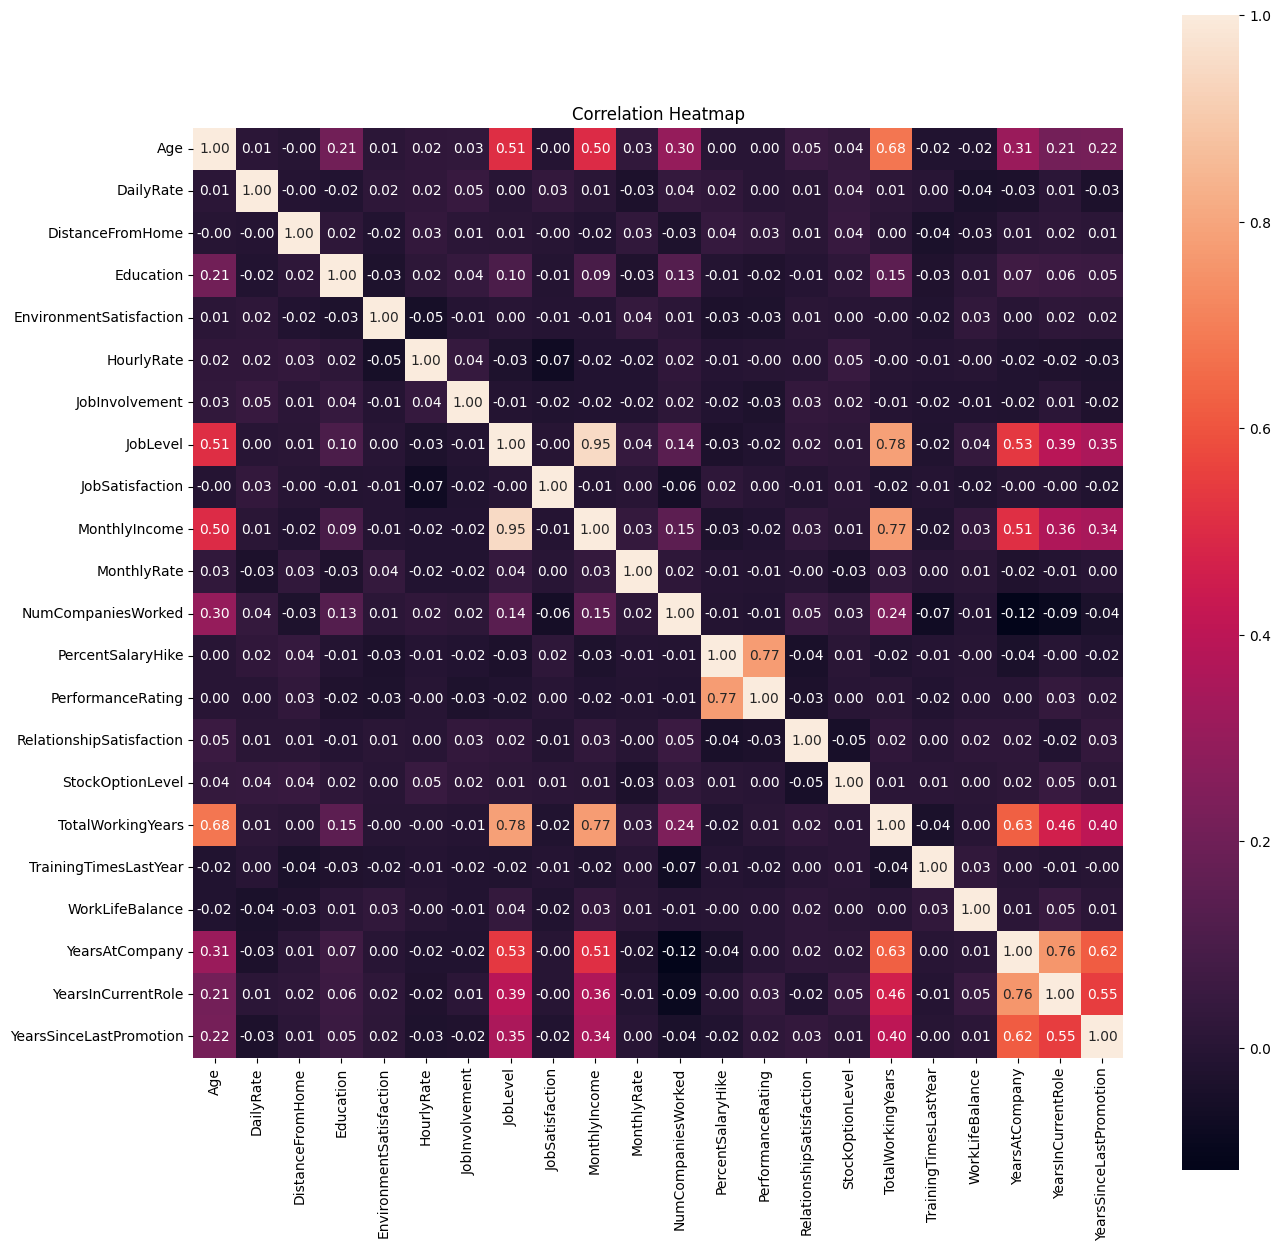

In [15]:
## Correlation Heatmap
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', square=True)
plt.title("Correlation Heatmap") 
plt.show()

## 6. Preprocessing Setup
### Define categorical and numeric preprocessing and build a ColumnTransformer pipeline.

In [16]:


# Use a proper preprocessing pipeline instead of label encoding all categorical columns
X = df.drop('Attrition', axis=1)
y = df['Attrition'].map({'Yes': 1, 'No': 0}) if df['Attrition'].dtype == 'object' else df['Attrition']

categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

## 7. Train/Test Split
### Split the dataset into training and testing sets with stratification for balanced classes.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((1176, 32), (294, 32))

## 8. Model Training
### Train a logistic regression model using the preprocessing pipeline.

In [18]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear'))
])

clf.fit(X_train, y_train)
print("Model Training Completed")

Model Training Completed


## 9. Evaluation
### Generate predictions on the test set and compute accuracy, confusion matrix, and classification metrics.

In [19]:
## Evaluation Function
def evaluate_model(name, clf, X_test, y_test, threshold=0.5):

    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # Convert string labels to numeric if needed
    if y_test.dtype == 'string':
        y_test = y_test.map({'No': 0, 'Yes': 1})

    print("\n" + "=" * 50)
    print(f"  {name} (threshold={threshold})")
    print("=" * 50)

    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  F1-Score : {f1_score(y_test, y_pred):.4f}")

    print()
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Stay', 'Leave']
    ))
    return y_prob
prob = evaluate_model('Model LR',clf, X_test, y_test)


  Model LR (threshold=0.5)
  Accuracy : 0.8980
  ROC-AUC  : 0.8893
  F1-Score : 0.6429

              precision    recall  f1-score   support

        Stay       0.92      0.96      0.94       247
       Leave       0.73      0.57      0.64        47

    accuracy                           0.90       294
   macro avg       0.83      0.77      0.79       294
weighted avg       0.89      0.90      0.89       294



Best threshold: 0.406 → F1: 0.7021


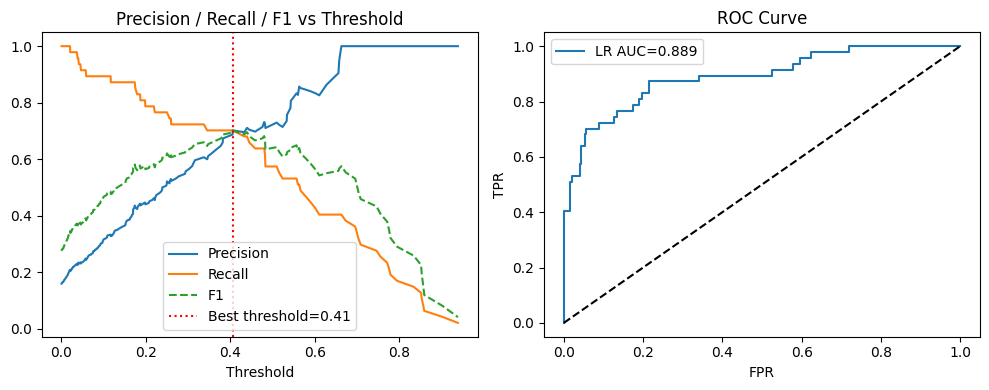

In [20]:
## Find optimal threshold using Precision-Recall curve
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)  # No=0, Yes=1

precision, recall, thresholds = precision_recall_curve(
    y_test_encoded,
    prob
)

f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f'Best threshold: {best_threshold:.3f} → F1: {f1_scores[best_idx]:.4f}')


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], '--', label='F1')
plt.axvline(best_threshold, color='red', linestyle=':',
            label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test_encoded, prob)
auc = roc_auc_score(y_test_encoded, prob)
plt.plot(fpr, tpr, label=f'LR AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
print(f'CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Fold scores: {np.round(cv_scores, 4)}')

CV ROC-AUC: 0.8385 ± 0.0236
Fold scores: [0.8837 0.8189 0.821  0.8378 0.8312]


<!-- ## 10. Model Explainability
### Use SHAP to interpret feature importance for the trained logistic regression model. -->

In [ ]:
# df.to_csv("Cleaned_HR_attrition_data.csv", index=False)

In [ ]:
# import joblib
# joblib.dump(clf, "Model.pkl")

['Model.pkl']